## Universal Vars

In [1]:
# Set to True to output a PGF file for LaTeX.
# Set to False to output a high-DPI JPG file.
USE_PGF = False

## Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sns
from functools import reduce
import math
import os

# --- CONDITIONAL BACKEND & LIBRARY IMPORT ---
if USE_PGF:
    mpl.use("pgf")
    mpl.rcParams['pgf.texsystem'] = 'pdflatex'
    import matplotlib.pyplot as plt
    print("Using PGF backend for LaTeX export.")
else:
    import matplotlib.pyplot as plt
    print("Using default backend for standard image export.")

Using default backend for standard image export.


## Read

In [3]:
df = pd.read_csv('SolStats.csv')

In [4]:
df

,instance,|V|,|A|,|B|,T,model,cost,meters,tourMinutes,blocksMeters,blocksMinutes,numVisitedBlocks,numVisitedNodes,numOriginalVisitedNodes,numRepeatedNodes,numRepeatedArcs,Components,ComponentsSelection,Profits,Algorithm
0,10,75,5550,10,120,SOL-STATS,51,20524,30.786,4027,24.162,10,156,491,128,61,single,random,random,IP
1,11,105,10920,15,120,SOL-STATS,56,29838,44.757,6309,37.854,15,292,767,202,174,single,random,random,IP
2,12,107,11342,15,120,SOL-STATS,48,36902,55.353,5624,33.744,15,301,941,240,247,single,random,random,IP
3,13,116,13340,15,120,SOL-STATS,73,29818,44.727,4861,29.166,15,345,825,200,170,single,random,random,IP
4,14,96,9120,15,120,SOL-STATS,55,27188,40.782,5800,34.800,15,252,627,173,152,single,random,random,IP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275,79,668,445556,80,120,SOL-STATS,39,17206,25.809,15562,93.372,39,141,602,10,2,multiple,sparse,unitary,BRKGA
1276,7,97,9312,10,120,SOL-STATS,10,28414,42.621,2919,17.514,10,30,842,34,0,multiple,sparse,unitary,BRKGA
1277,80,667,444222,80,120,SOL-STATS,39,17206,25.809,15562,93.372,39,141,602,10,2,multiple,sparse,unitary,BRKGA
1278,8,95,8930,10,120,SOL-STATS,10,26994,40.491,2492,14.952,10,28,857,69,0,multiple,sparse,unitary,BRKGA


## Preprocess

In [5]:
TIME_LIMIT = 120

### Rename columns

In [6]:
df['tourMeters'] = df['meters']
df['numVisitedBlocksNodes'] = df['numVisitedNodes']
df['numVisitedNodes'] = df['numOriginalVisitedNodes']
#df['tourMinutes'] -= df['blocksMinutes']

### Drop columns

In [7]:
df = df.drop(columns=['meters', 'cost', 'model', 'numOriginalVisitedNodes'])

### Sorting

In [8]:
df.sort_values(by=['Algorithm', 'Profits', 'ComponentsSelection', 'Components', 'instance'], inplace=True)

### Percentages

In [9]:
df['%numVisitedBlocks'] = np.where(
    df['|B|'] == 0,
    0,  # Set to 0 
    100 * df['numVisitedBlocks'] / df['|B|']  # Otherwise, perform the division
)

In [10]:
df['%numVisitedBlocksNodes'] = np.where(
    df['numVisitedNodes'] == 0,
    0,  # Set to 0 
    100 * df['numVisitedBlocksNodes'] / df['numVisitedNodes']   # Otherwise, perform the division
)

In [11]:
df['%repeatedArcs'] = np.where(
    df['numVisitedNodes'] - 1 == 0,
    0,  # Set to 0 
    100 * df['numRepeatedArcs'] / (df['numVisitedNodes'] - 1)  # Otherwise, perform the division
)
df['%repeatedNodes'] = np.where(
    df['numVisitedNodes'] == 0,
    0,  # Set to 0 
    100 * df['numRepeatedNodes'] / df['numVisitedNodes']  # Otherwise, perform the division
)

In [12]:
max_time = (df['tourMinutes'] + df['blocksMinutes']).clip(lower=TIME_LIMIT) 
df['%tourTotalMinutes'] = np.where(
    max_time == 0,
    0,  # Set to 0 
    100 * df['tourMinutes'] / max_time  # Otherwise, perform the division
)
df['%blocksTotalMinutes'] = np.where(
    max_time == 0,
    0,  # Set to 0 
    100 * df['blocksMinutes'] / max_time  # Otherwise, perform the division
)

In [13]:
sol_time = (df['tourMinutes'] + df['blocksMinutes'])
df['%tourMinutes'] = np.where(
    sol_time == 0,
    0,  # Set to 0 
    100 * df['tourMinutes'] / sol_time  # Otherwise, perform the division
)
df['%blocksMinutes'] = np.where(
    sol_time == 0,
    0,  # Set to 0 
    100 * df['blocksMinutes'] / sol_time  # Otherwise, perform the division
)

In [14]:
# Get all column names that start with '%'
PERCENTAGE_COLUMNS = [col for col in df.columns if col.startswith('%')]
PERCENTAGE_COLUMNS

['%numVisitedBlocks',
 '%numVisitedBlocksNodes',
 '%repeatedArcs',
 '%repeatedNodes',
 '%tourTotalMinutes',
 '%blocksTotalMinutes',
 '%tourMinutes',
 '%blocksMinutes']

In [15]:
df[df['%numVisitedBlocksNodes'] == 100][['numVisitedNodes', 'numVisitedBlocksNodes']]

,numVisitedNodes,numVisitedBlocksNodes
115,14,14
117,7,7
118,26,26
119,24,24
122,21,21
...,...,...
550,20,20
551,20,20
552,20,20
553,6,6


### Save

In [56]:
df.columns

Index(['instance', '|V|', '|A|', '|B|', 'T', 'tourMinutes', 'blocksMeters',
       'blocksMinutes', 'numVisitedBlocks', 'numVisitedNodes',
       'numRepeatedNodes', 'numRepeatedArcs', 'Components',
       'ComponentsSelection', 'Profits', 'Algorithm', 'tourMeters',
       'numVisitedBlocksNodes', '%numVisitedBlocks', '%numVisitedBlocksNodes',
       '%repeatedArcs', '%repeatedNodes', '%tourTotalMinutes',
       '%blocksTotalMinutes', '%tourMinutes', '%blocksMinutes'],
      dtype='object')

In [60]:
df[['instance', '|V|', '|A|', '|B|', 'T',  'Components',
       'ComponentsSelection', 'Profits', 'Algorithm', 
    '%numVisitedBlocks', '%numVisitedBlocksNodes',
       '%repeatedArcs', '%repeatedNodes', '%tourTotalMinutes',
       '%blocksTotalMinutes', '%tourMinutes', '%blocksMinutes']].to_csv('SolStatsProcessed.csv', index=False)

### Creating Keys

In [16]:
MAX_INSTANCE = 80

In [17]:
MAIN_KEYS = ['Algorithm', 'Profits', 'ComponentsSelection', 'Components']

In [18]:
keys = df[MAIN_KEYS].drop_duplicates(subset=MAIN_KEYS)

In [19]:
def filterByKey(key):
    # Build a list of boolean Series for each condition
    conditions = [(df[col] == key[col]) for col in MAIN_KEYS]
    
    # Combine the conditions using the bitwise AND (&) operator
    # reduce applies the & operator cumulatively to all conditions
    combined_condition = reduce(lambda x, y: x & y, conditions)
    
    # Filter the DataFrame using the combined condition
    return df[combined_condition]

In [62]:
keys.to_csv('Keys.csv', index=False)

## Averages

In [20]:
def get_averages_by_instance_range_fixed(df):
    """
    Groups a DataFrame by instance range and calculates the average of numeric columns.
    
    Args:
        df (pd.DataFrame): The input DataFrame.
    
    Returns:
        pd.DataFrame: A DataFrame with the averages for each instance range.
    """
    # Use a copy of the dataframe to avoid the SettingWithCopyWarning.
    df_copy = df.copy()
    
    # Create the instance ranges using .loc to avoid the warning.
    df_copy.loc[:, 'instance_range'] = (df_copy['instance'] - 1) // 5
    
    # Group by the instance range and calculate the mean for all numeric columns.
    df_avg = df_copy.groupby('instance_range').mean(numeric_only=True)
    
    # Create a descriptive 'range' column and set it as the index.
    #df_avg['range'] = df_avg.index.map(lambda x: f"{x*5 + 1}-{x*5 + 5}")
    df_avg['range'] = df_avg.index.map(lambda x: f"{x*5 + 5}")
    df_avg = df_avg.set_index('range')
    
    # Drop the temporary 'instance_range' column if it exists.
    #if 'instance_range' in df_avg.columns:
    df_avg = df_avg.drop(columns=['instance', '|V|', '|A|', '|B|', 'T'])
        
    return df_avg

### By Key

In [21]:
df_per_key = dict()

In [22]:
for index, key in keys.iterrows():  
    filtered_df = filterByKey(key)
    df_per_key[tuple(key.values)] = get_averages_by_instance_range_fixed(filtered_df)

## Plots

### Scatter Plots

In [31]:
def plot_combined_percentage_columns(df, percentage_columns, output_file='combined_percentage_scatter'):
    """
    Creates a single scatter plot for all specified columns, using different markers for each.

    Args:
        df (pd.DataFrame): The input DataFrame.
        percentage_columns (list): A list of column names to plot.
        output_file (str): The filename to save the single plot.
    """
    plt.figure(figsize=(14, 8)) # Increased figure size for better visibility

    # Define a list of distinct markers
    # You can expand this list if you have more columns than markers
    markers = ['o', 's', '^', 'D', 'p', '*', 'x', 'v', '<', '>', 'h', 'H', 'd', 'P', 'X']
    
    # Ensure we have enough markers for all columns
    if len(percentage_columns) > len(markers):
        print("Warning: Not enough unique markers for all columns. Some markers will be repeated.")
        # Extend markers list if necessary by repeating
        markers = (markers * (len(percentage_columns) // len(markers) + 1))[:len(percentage_columns)]

    for i, col in enumerate(percentage_columns):
        plt.scatter(df.index, df[col], label=col, marker=markers[i], s=50) # s for marker size

    plt.title('Combined Scatter Plot of Percentage Columns (with distinct markers)', fontsize=16)
    plt.xlabel('Range', fontsize=12)
    plt.ylabel('Percentage', fontsize=12)
    plt.grid(True)
    #plt.legend(title='Columns', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for the legend

    # --- CONDITIONAL EXPORTING ---
    if USE_PGF:
        plt.savefig(output_file + '.pgf')
        print(f"PGF vector plot saved to '{output_file + '.pgf'}'")
    else:        
        plt.savefig(output_file + '.png', dpi=300) # Use a high DPI for better quality
        print(f"JPG raster plot saved to '{output_file + '.png'}'")    
    plt.show()


JPG raster plot saved to 'combined_percentage_scatter.png'


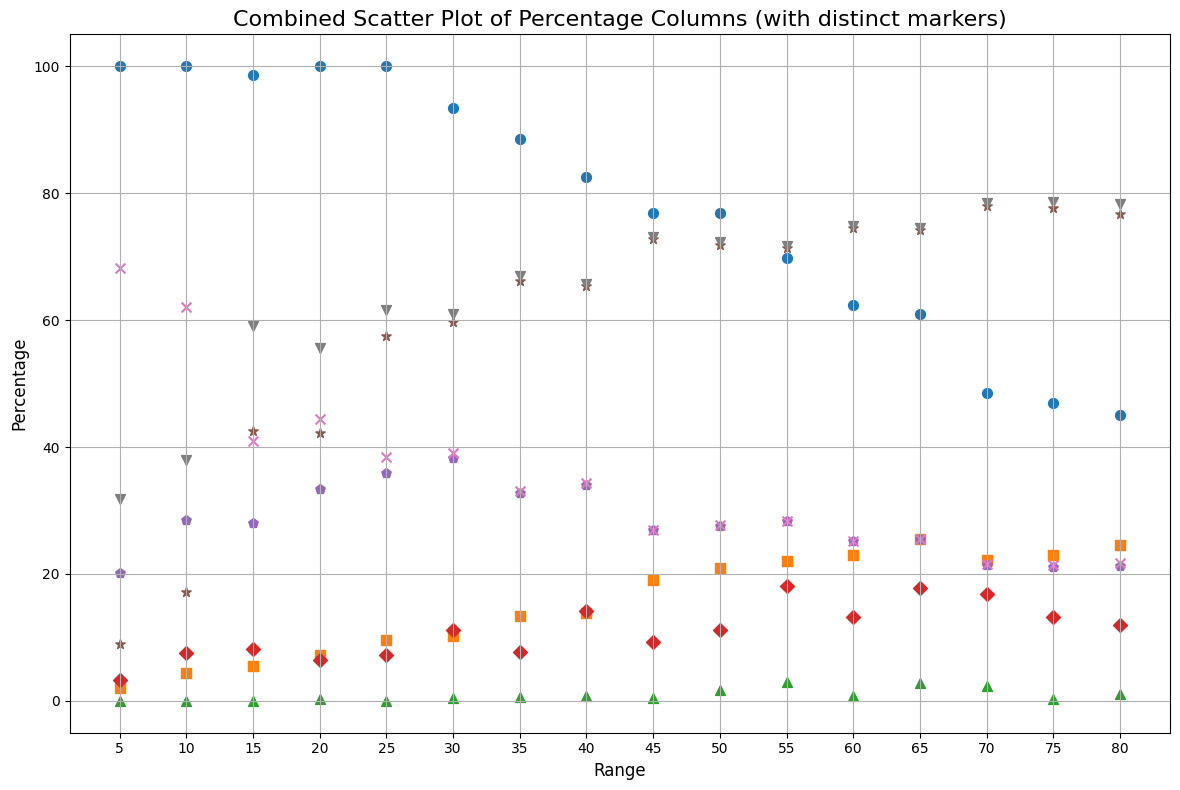

In [32]:
plot_combined_percentage_columns(df_per_key[tuple(keys.iloc[0].values)], PERCENTAGE_COLUMNS)

In [48]:
def plot_combined_percentage_columns_line(df, percentage_columns, output_file='combined_percentage_line_plot'):
    """
    Creates a single line plot for all specified columns, using different markers for each.

    Args:
        df (pd.DataFrame): The input DataFrame.
        percentage_columns (list): A list of column names to plot.
        output_file (str): The filename to save the single plot.
    """
    plt.figure(figsize=(14, 8))

    # Define a list of distinct markers
    markers = ['o', 's', '^', 'D', 'p', '*', 'x', 'v', '<', '>', 'h', 'H', 'd', 'P', 'X']

    if len(percentage_columns) > len(markers):
        print("Warning: Not enough unique markers for all columns. Some markers will be repeated.")
        markers = (markers * (len(percentage_columns) // len(markers) + 1))[:len(percentage_columns)]

    for i, col in enumerate(percentage_columns):
        plt.plot(df.index, df[col], label=col, marker=markers[i], markersize=6)

    #plt.title('Combined Line Plot of Percentage Columns', fontsize=16)
    #plt.xlabel('Range', fontsize=12)
    #plt.ylabel('Percentage', fontsize=12)
    plt.grid(True)
    #plt.legend(title='Columns', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # --- CONDITIONAL EXPORTING ---
    if USE_PGF:
        plt.savefig(output_file + '.pgf')
        print(f"PGF vector plot saved to '{output_file + '.pgf'}'")
    else:        
        plt.savefig(output_file + '.png', dpi=300) # Use a high DPI for better quality
        print(f"JPG raster plot saved to '{output_file + '.png'}'")  
    plt.show()

JPG raster plot saved to 'combined_percentage_line_plot.png'


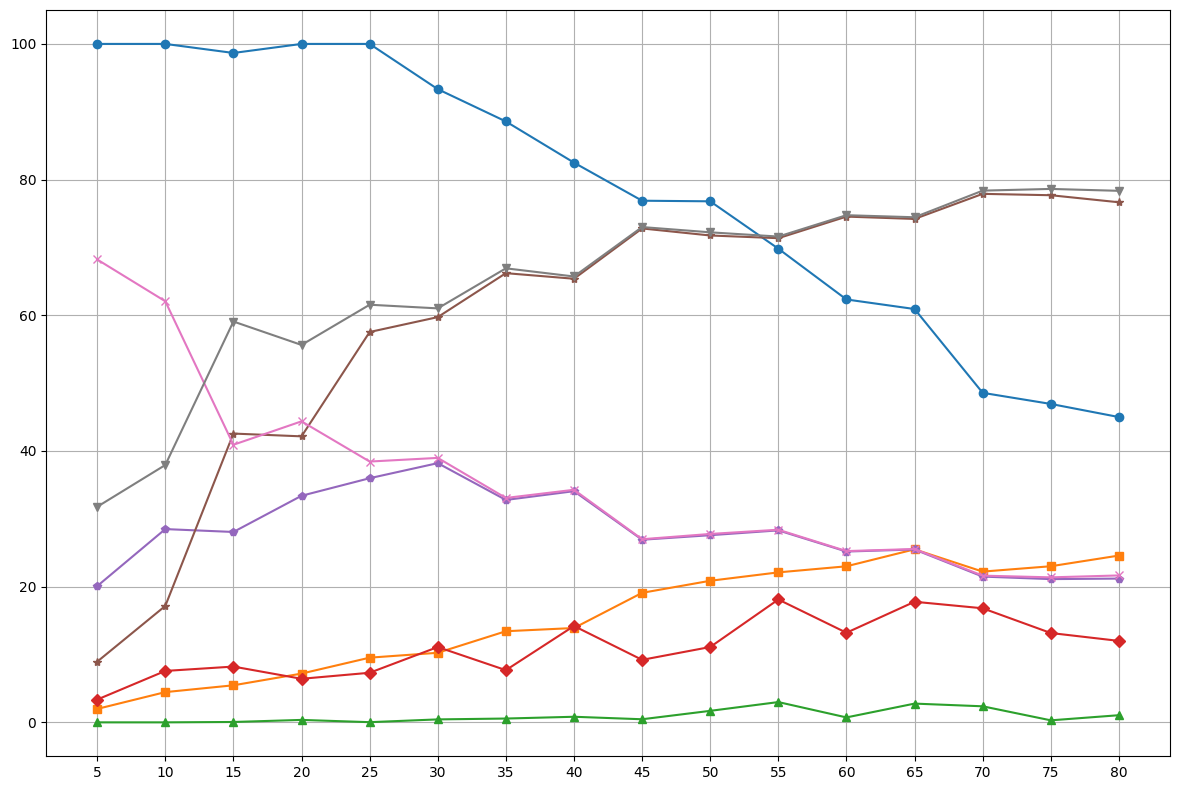

In [49]:
plot_combined_percentage_columns_line(df_per_key[tuple(keys.iloc[0].values)], PERCENTAGE_COLUMNS)

In [53]:
def getFileName(key_tuple):
    #
    alg_name, profit, component_type, component_qtt = key_tuple
    #
    alg_str = "BRKGA" if alg_name == "BRKGA" else "IP"
    #
    return alg_str + " Percentages per block of " + component_qtt + " component, " + profit + " profits, and " + component_type + " blocks"    

JPG raster plot saved to 'BRKGA Percentages per block of multiple component, random profits, and random blocks.png'


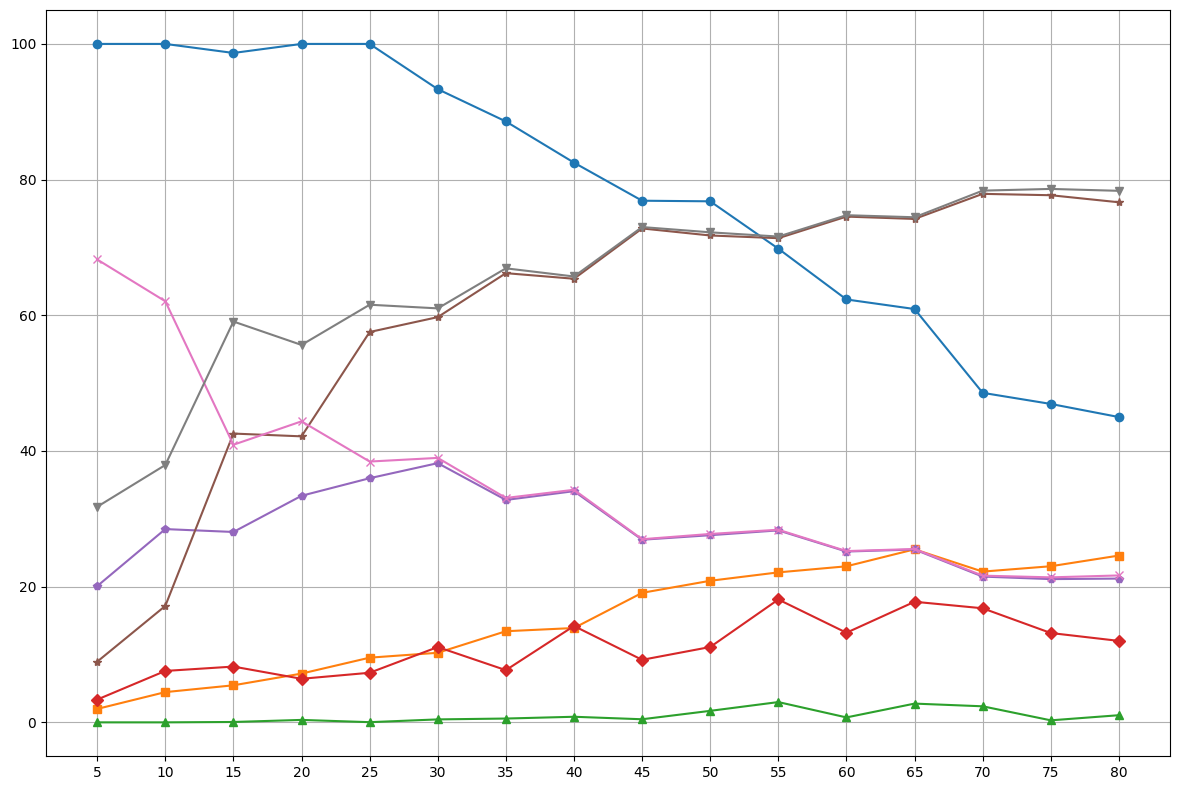

JPG raster plot saved to 'BRKGA Percentages per block of single component, random profits, and random blocks.png'


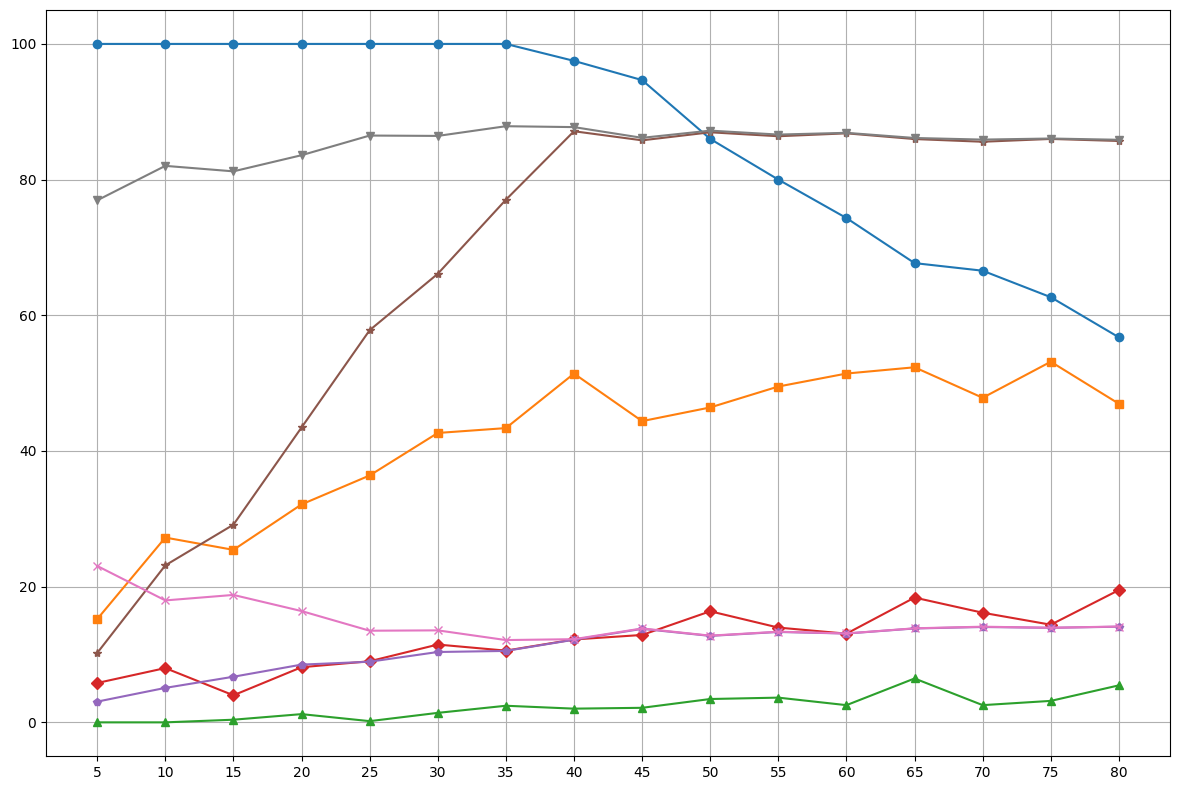

JPG raster plot saved to 'BRKGA Percentages per block of multiple component, random profits, and sparse blocks.png'


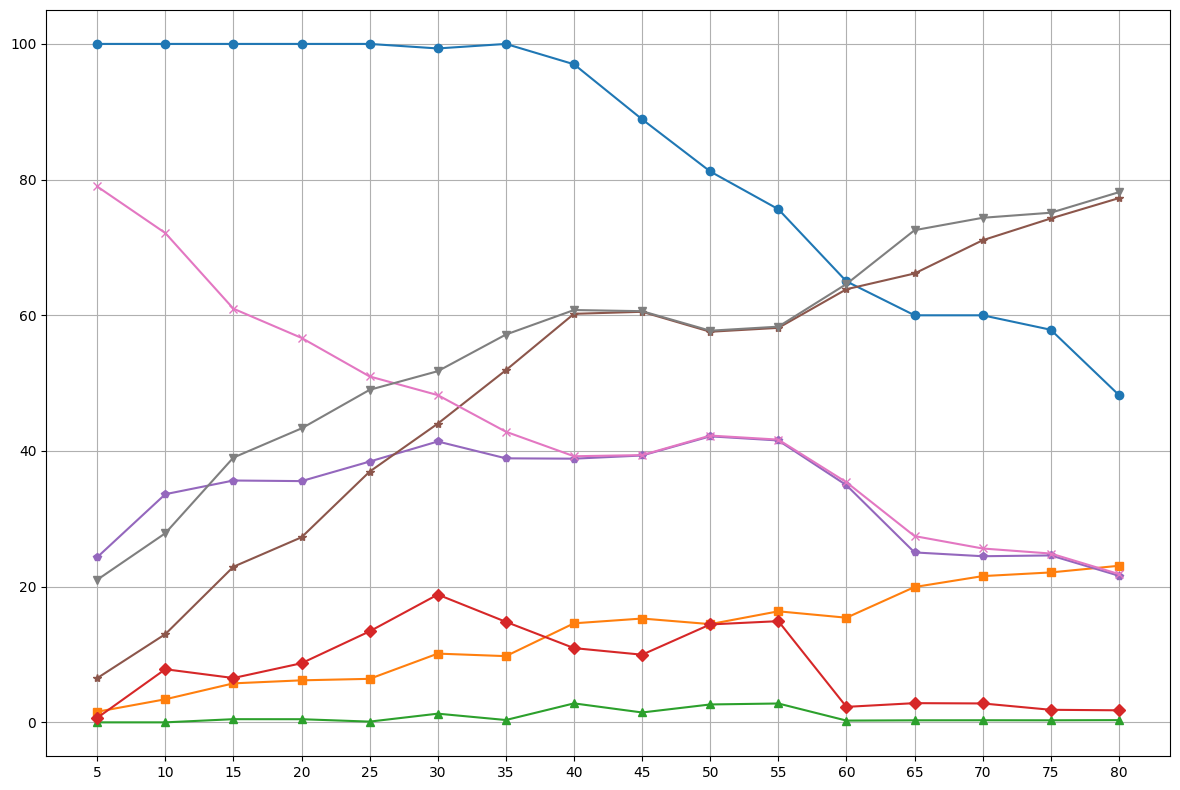

JPG raster plot saved to 'BRKGA Percentages per block of single component, random profits, and sparse blocks.png'


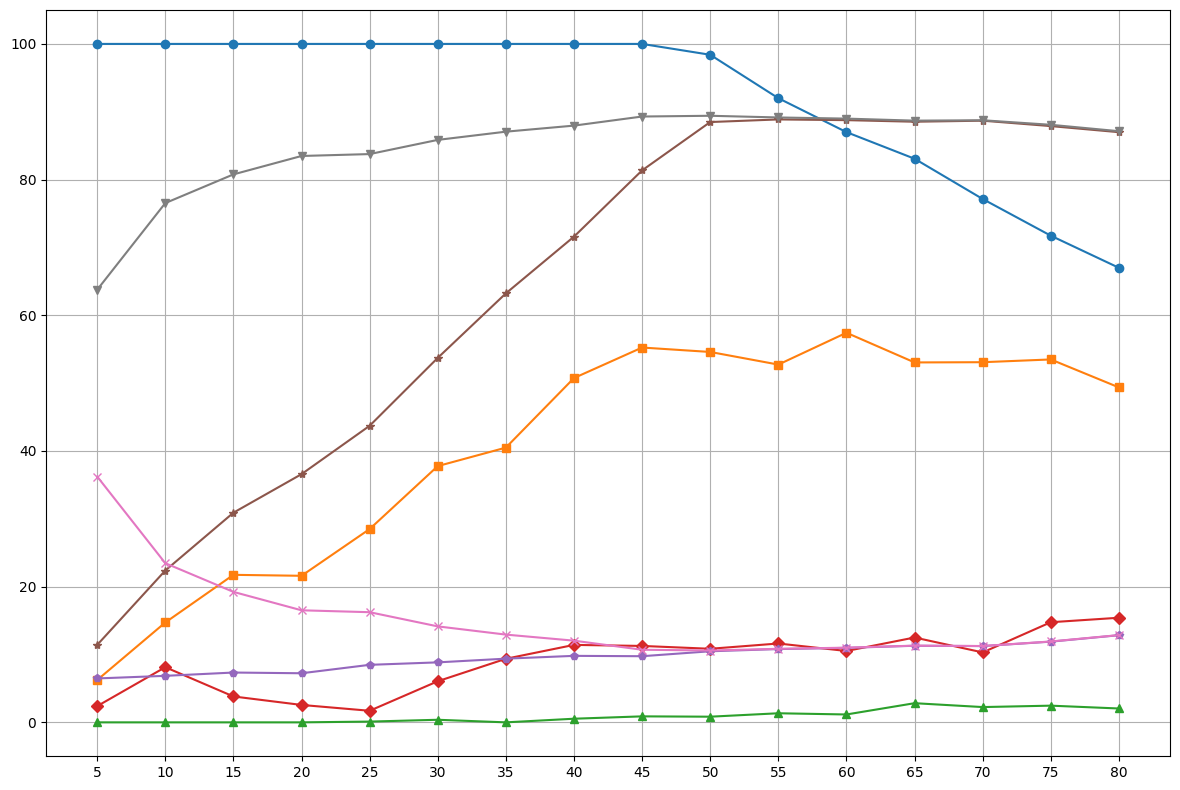

JPG raster plot saved to 'BRKGA Percentages per block of multiple component, unitary profits, and random blocks.png'


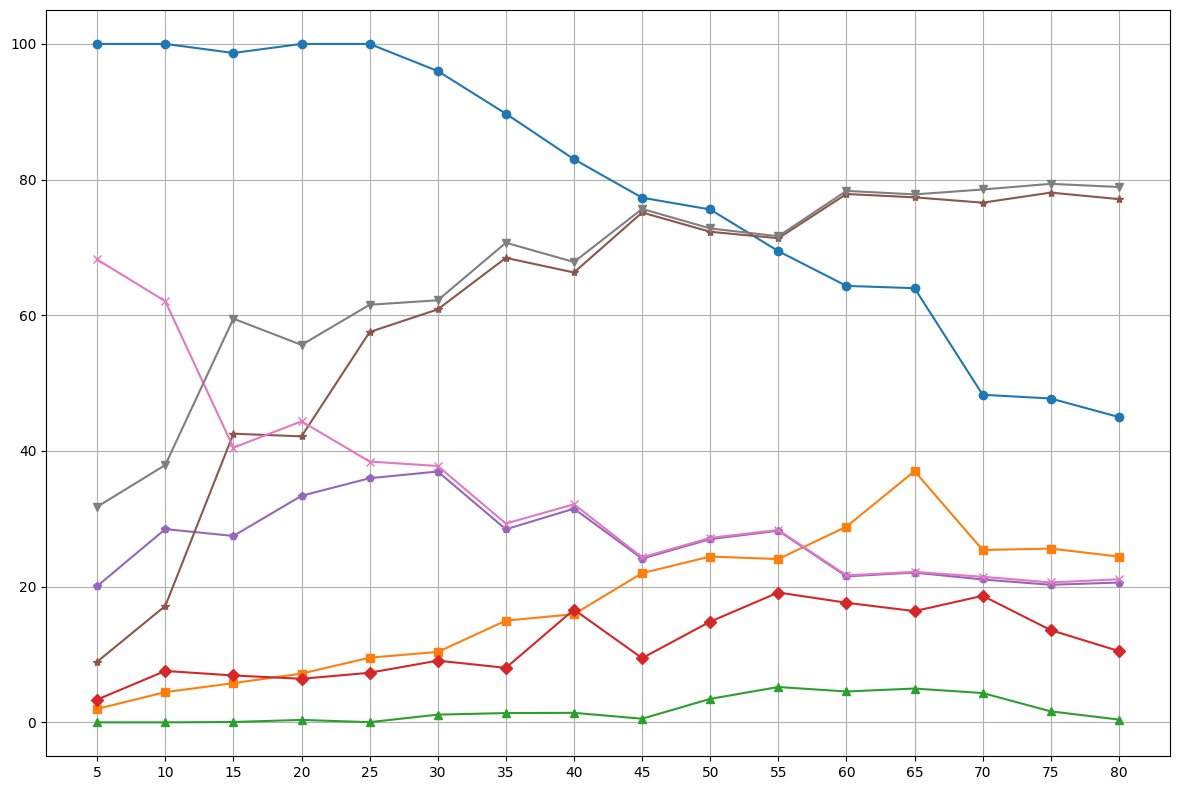

JPG raster plot saved to 'BRKGA Percentages per block of single component, unitary profits, and random blocks.png'


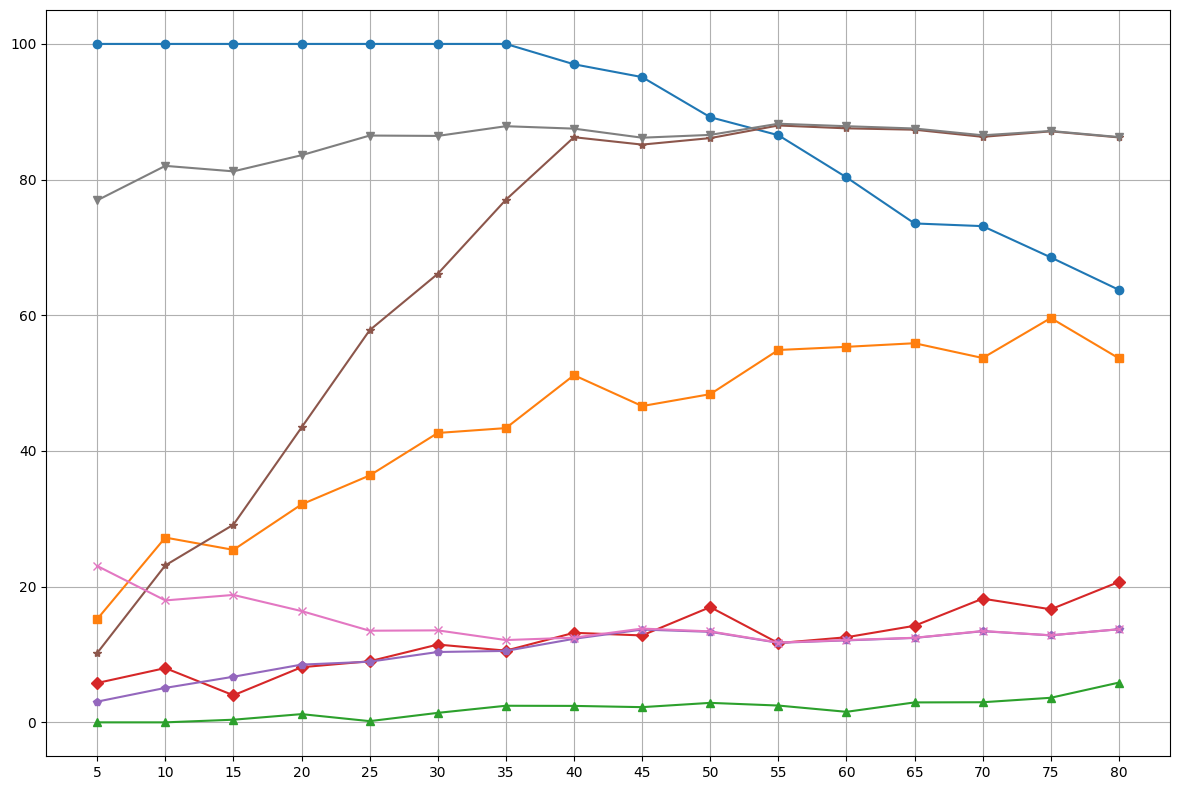

JPG raster plot saved to 'BRKGA Percentages per block of multiple component, unitary profits, and sparse blocks.png'


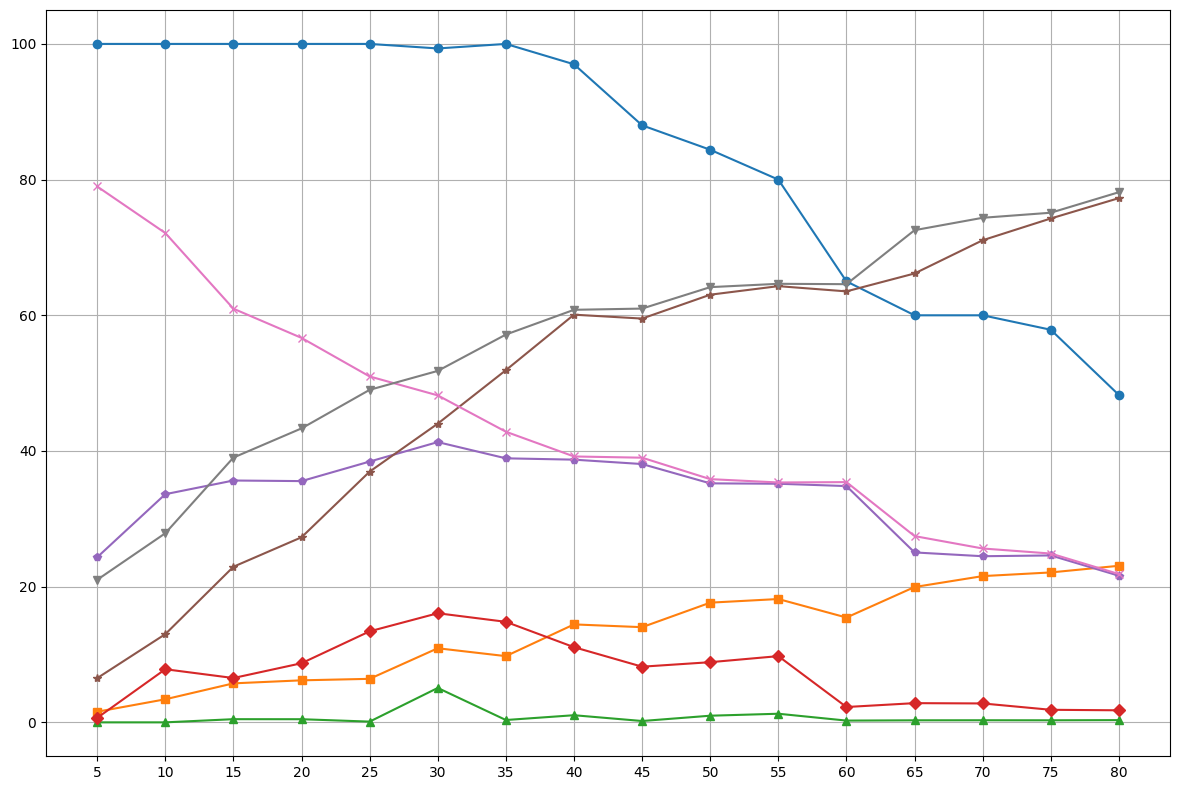

JPG raster plot saved to 'BRKGA Percentages per block of single component, unitary profits, and sparse blocks.png'


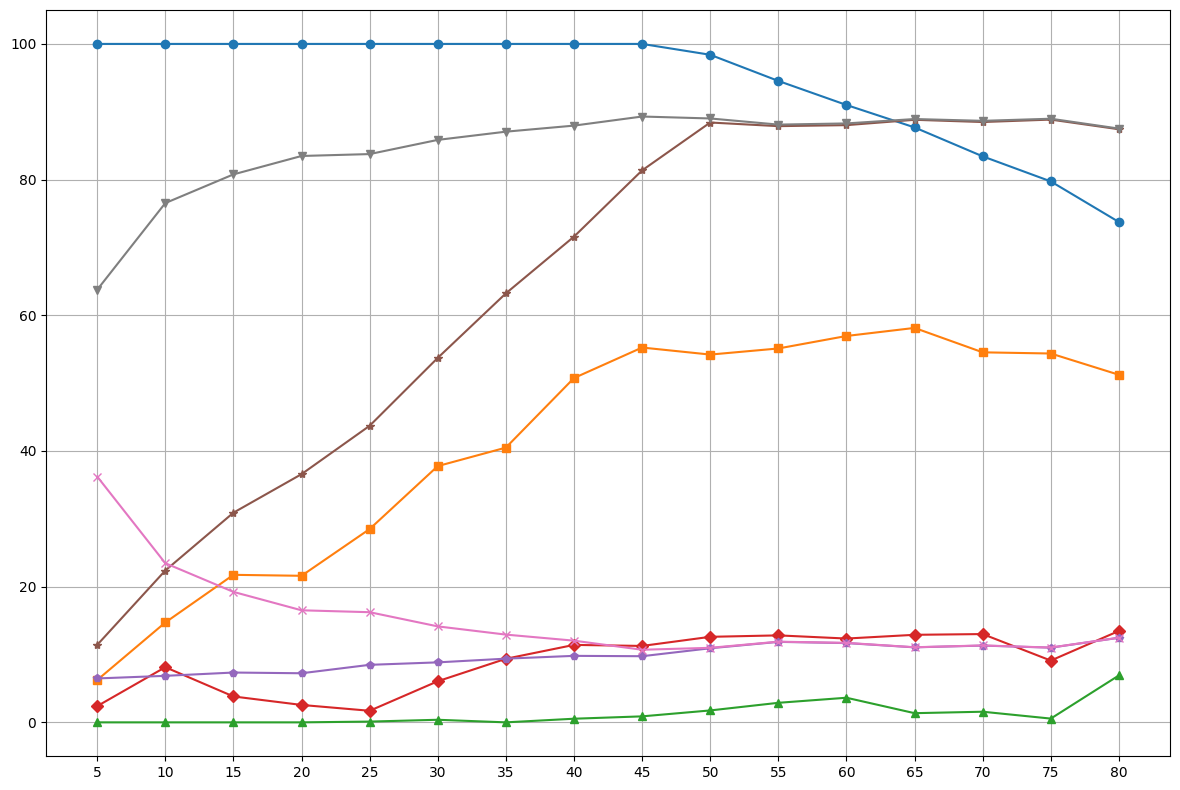

JPG raster plot saved to 'IP Percentages per block of multiple component, random profits, and random blocks.png'


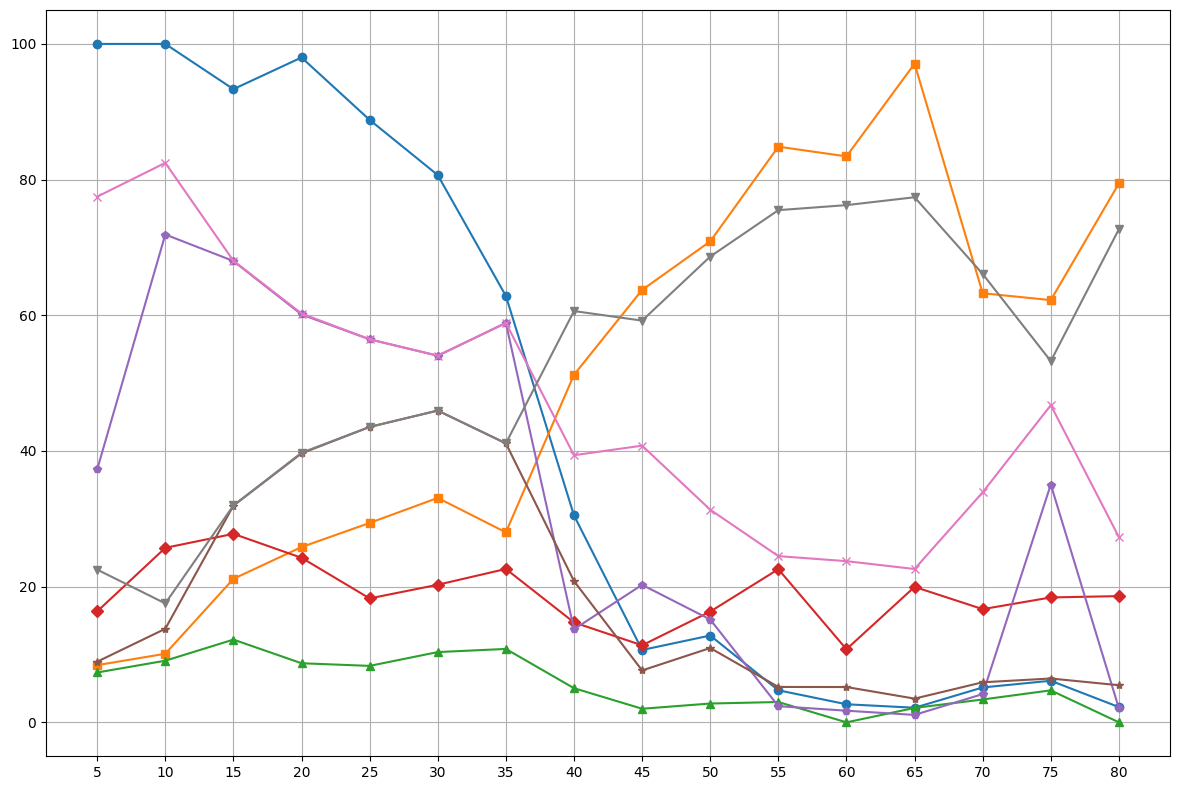

JPG raster plot saved to 'IP Percentages per block of single component, random profits, and random blocks.png'


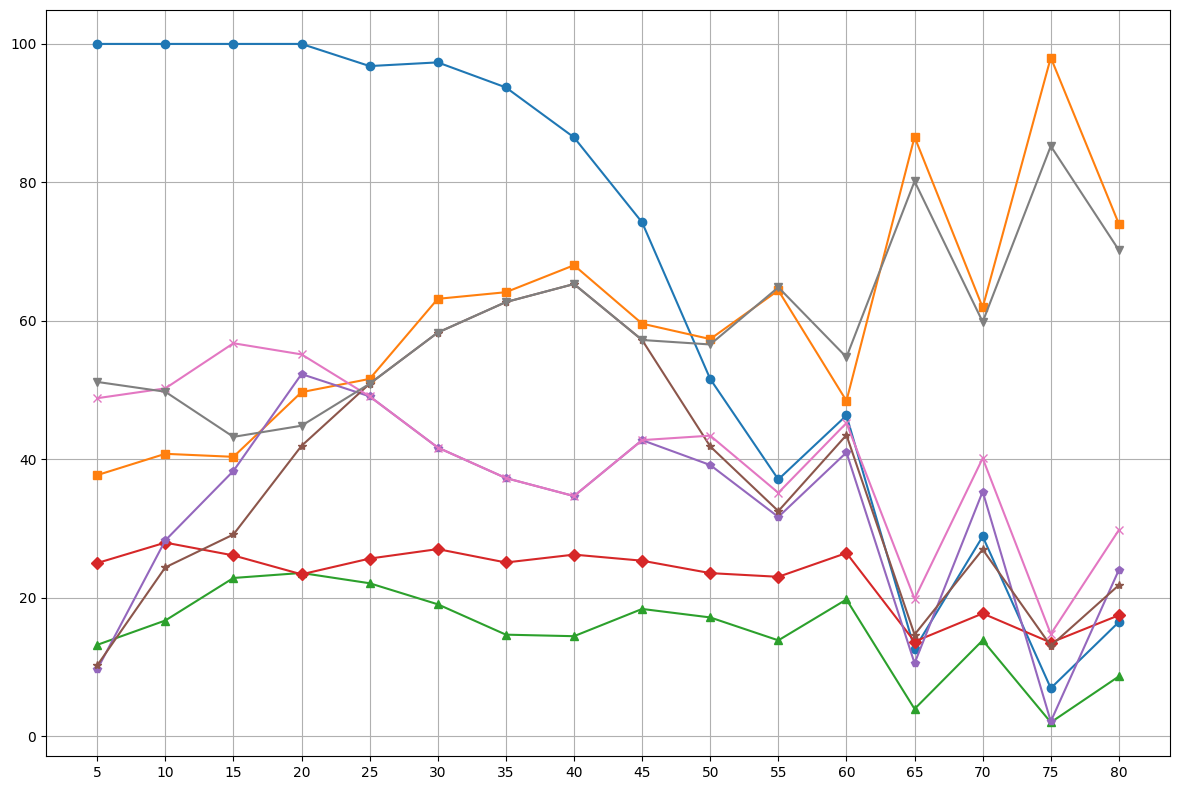

JPG raster plot saved to 'IP Percentages per block of multiple component, random profits, and sparse blocks.png'


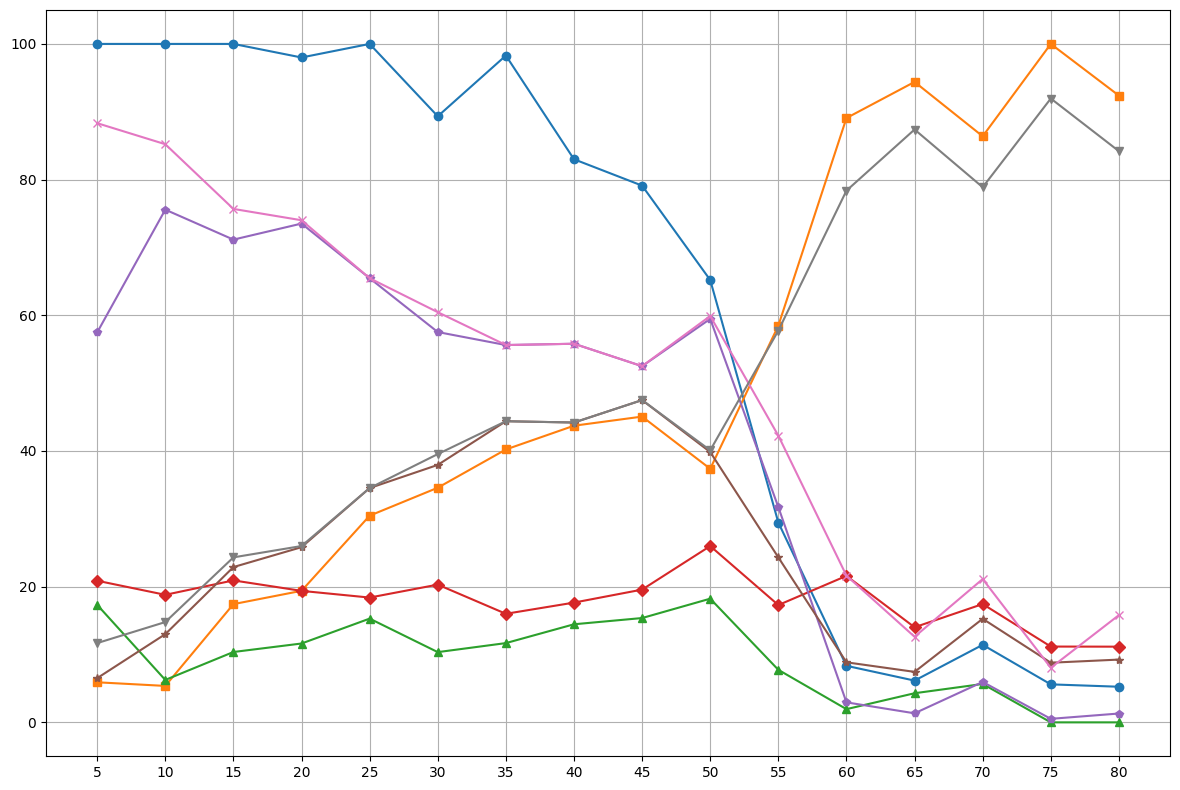

JPG raster plot saved to 'IP Percentages per block of single component, random profits, and sparse blocks.png'


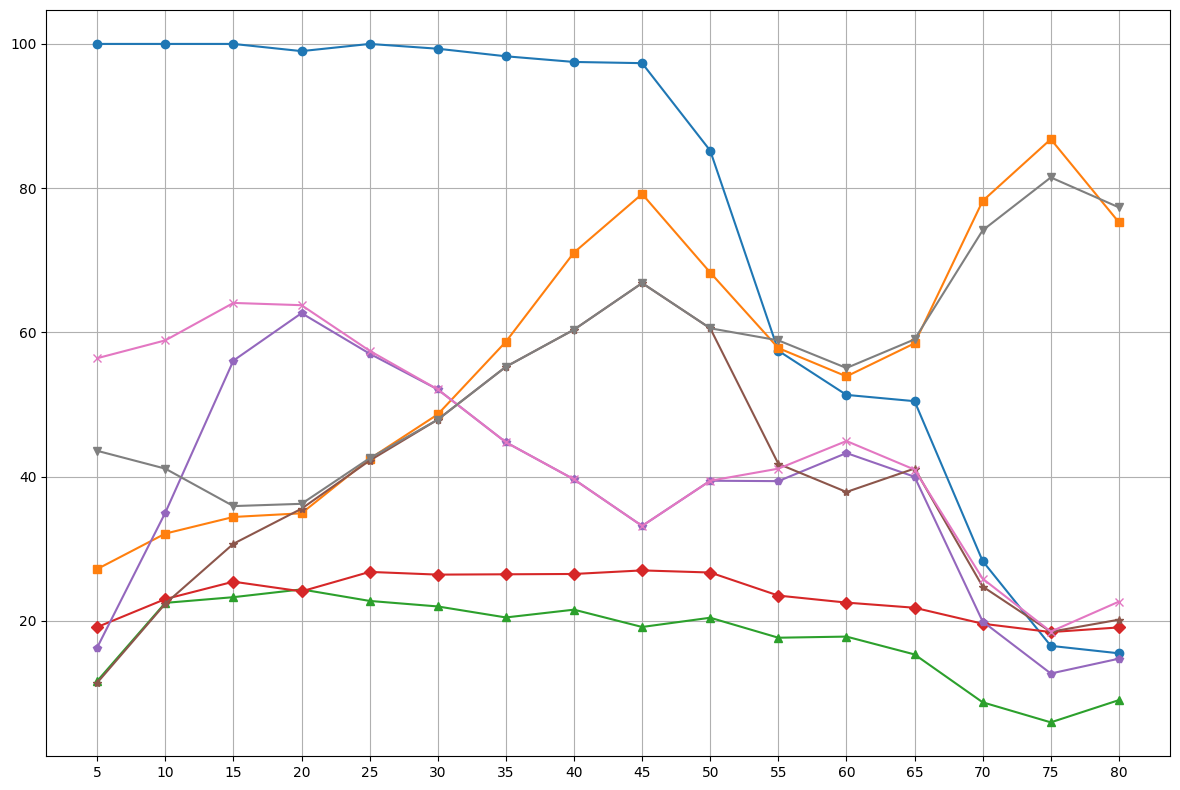

JPG raster plot saved to 'IP Percentages per block of multiple component, unitary profits, and random blocks.png'


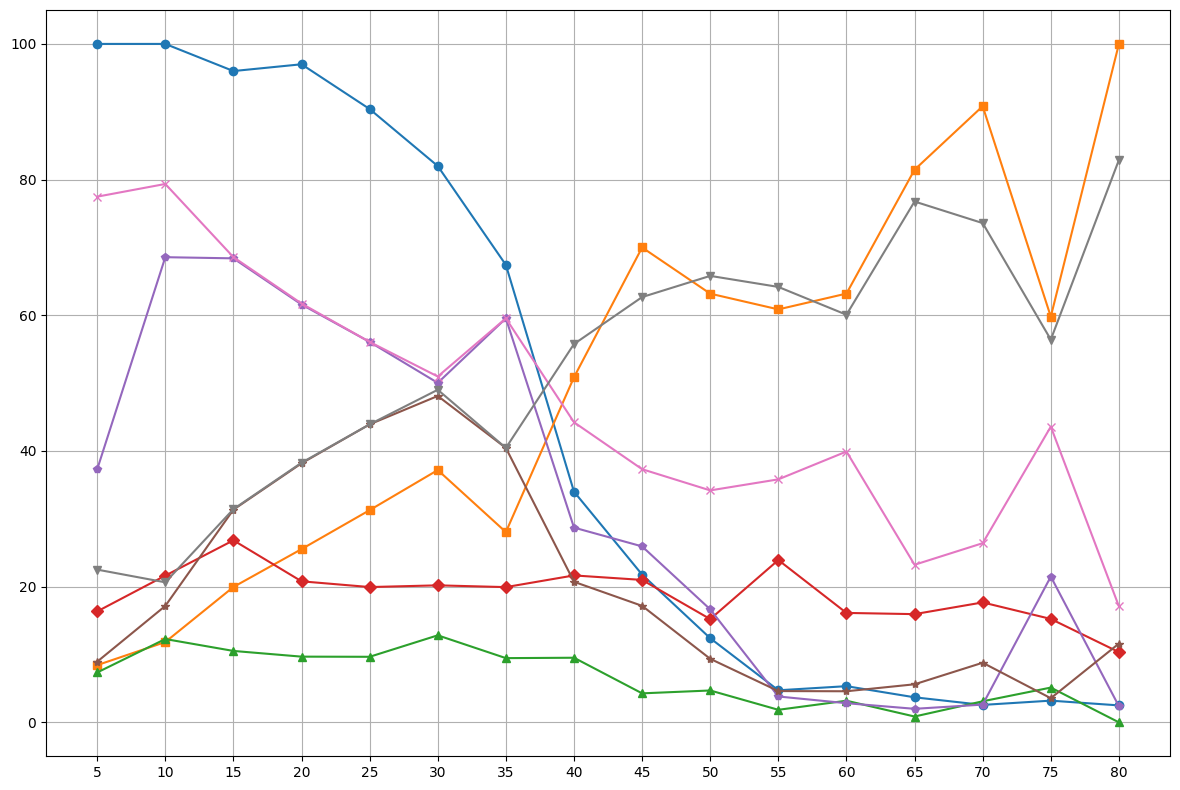

JPG raster plot saved to 'IP Percentages per block of single component, unitary profits, and random blocks.png'


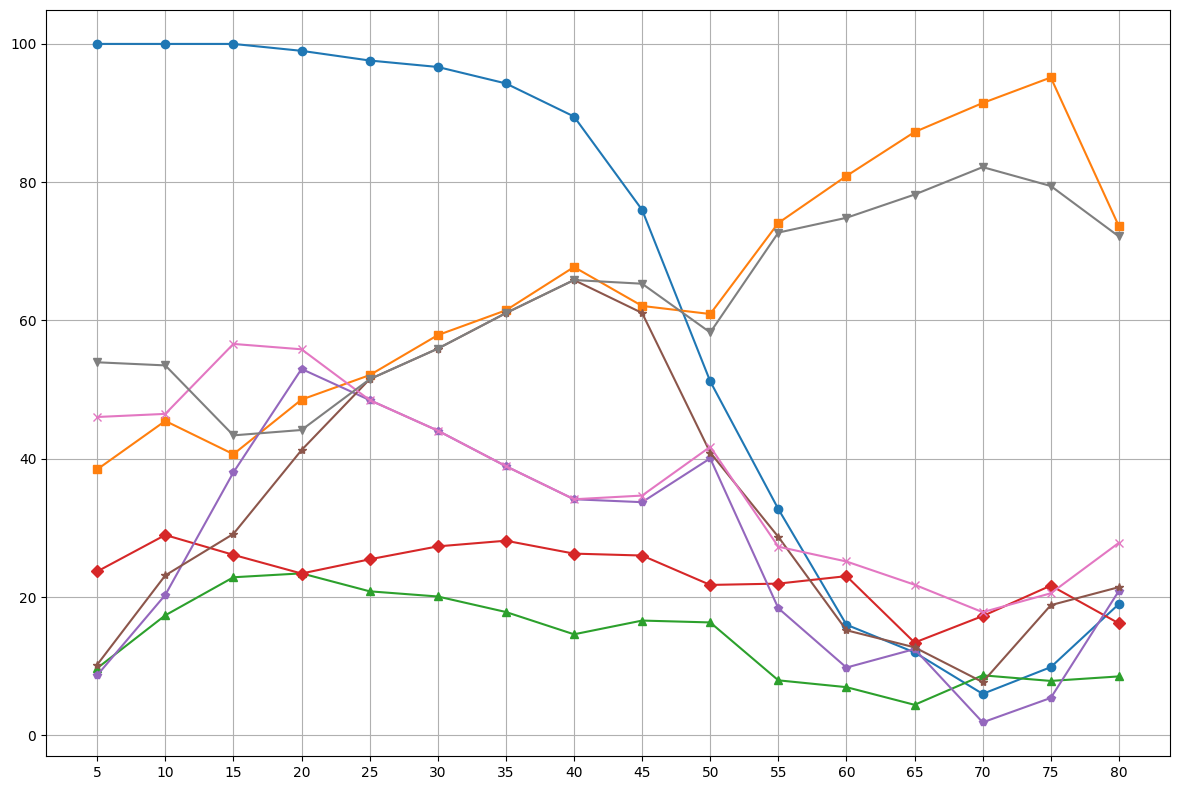

JPG raster plot saved to 'IP Percentages per block of multiple component, unitary profits, and sparse blocks.png'


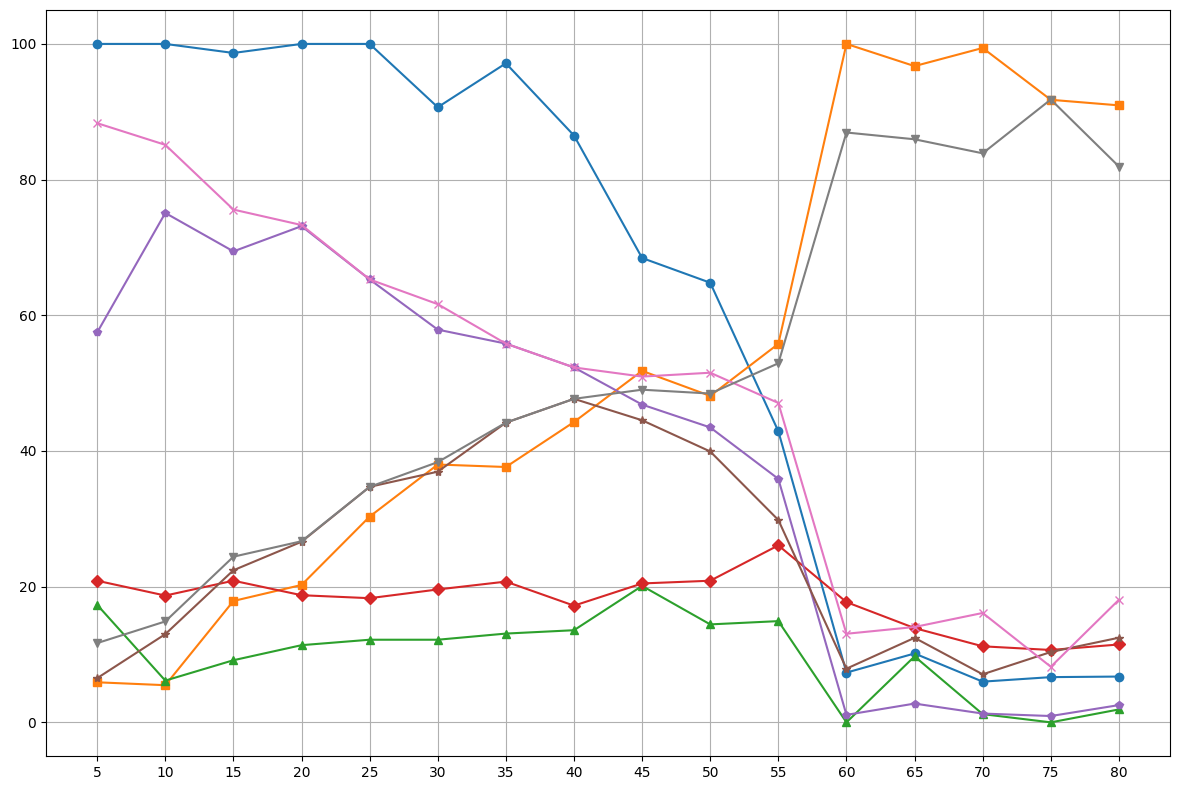

JPG raster plot saved to 'IP Percentages per block of single component, unitary profits, and sparse blocks.png'


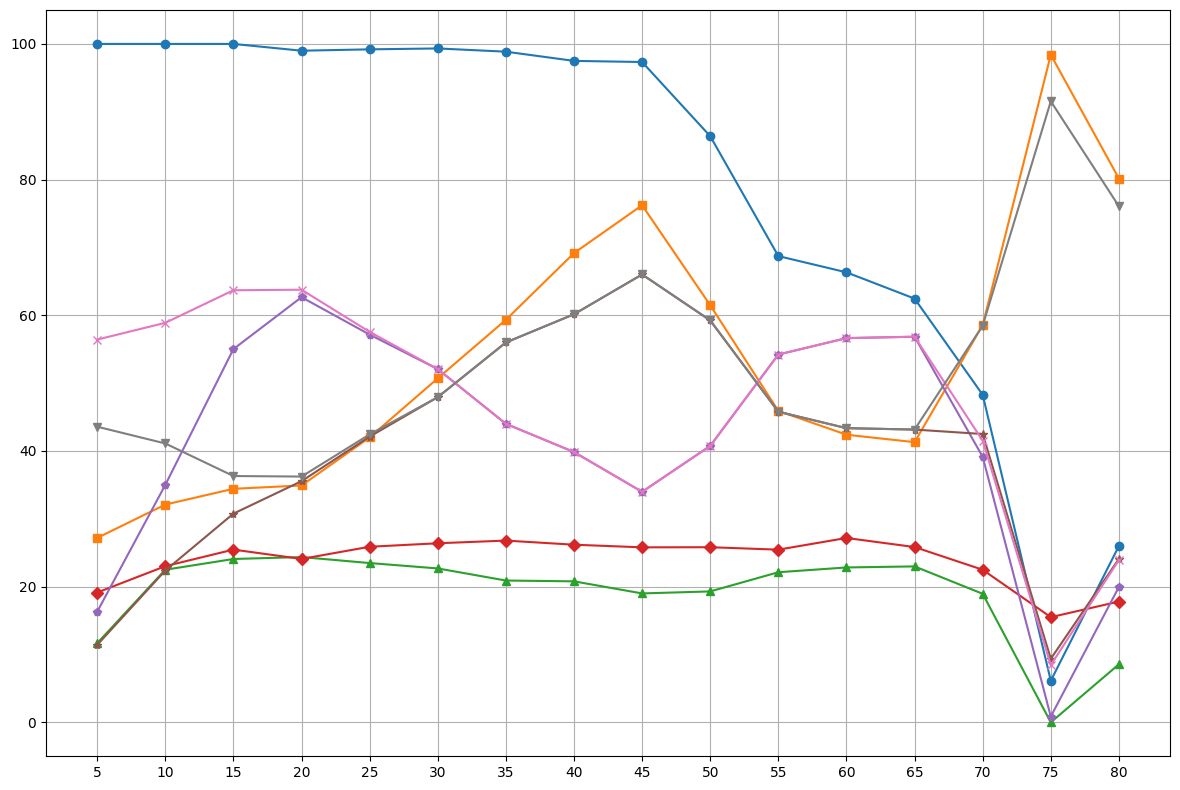

In [54]:
for index, key in keys.iterrows():  
    key_tuple = tuple(key.values)
    plot_combined_percentage_columns_line(df_per_key[key_tuple], PERCENTAGE_COLUMNS, getFileName(key_tuple))